<a href="https://colab.research.google.com/github/annyonok/my-portfolio/blob/main/%D0%9E%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Установка необходимых библиотек

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

## Импорт библиотек

In [2]:
import ultralytics                          # для обучения нейронной сети
from IPython.display import display, Image  # для работы с изображениями
import yaml                                 # для работы с файлом конфигурации
import os                                   # для работы с каталогами

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Подготовка датасета

In [3]:
HOME = os.getcwd()
print(HOME)

/content


In [6]:
# проверяем наличие архива с датасетом в папке
!ls

datasets  dataset.zip  sample_data


In [5]:
# создаем папку datasets/dataset и распаковываем в нее архив
!mkdir -p datasets/dataset && unzip -q dataset.zip -d datasets/dataset

In [7]:
%cd datasets/dataset/

/content/datasets/dataset


In [8]:
# Открываем файл конфигурации датасета
with open('data.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [9]:
print(config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['cars'], 'roboflow': {'workspace': 'annehome', 'project': 'search-for-cars', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/annehome/search-for-cars/dataset/1'}}


In [10]:
!ls

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [11]:
# проверяем файлы в датасете
img_list = os.listdir(config['train'].replace('../', ''))
print(len(img_list), *img_list[:5], sep='\n')
img_list = os.listdir(config['val'].replace('../', ''))
print(len(img_list), *img_list[:5], sep='\n')

74
video_hw_netology_mp4-0041_jpg.rf.42626f8331a936921f044ea941969c22.jpg
video_hw_netology_mp4-0016_jpg.rf.c3d937868a0c7e1ee1186cada33ea794.jpg
video_hw_netology_mp4-0072_jpg.rf.7fa55788a3094b84440e7e74c4c0f6d7.jpg
video_hw_netology_mp4-0075_jpg.rf.bb0a30e7fffb5b3eb9d62d90cedbadef.jpg
video_hw_netology_mp4-0044_jpg.rf.e9407a8796a95262d32b8909f2095bc0.jpg
10
video_hw_netology_mp4-0032_jpg.rf.4933ec3f937a3152763e8f7810ba0aaa.jpg
video_hw_netology_mp4-0024_jpg.rf.d4ec1dc6595cfbcd9da385c71eb54d24.jpg
video_hw_netology_mp4-0028_jpg.rf.350b6fd7e10e78f2214e60f2102f838d.jpg
video_hw_netology_mp4-0060_jpg.rf.36b68f208f25e549a0cddfc405bd1817.jpg
video_hw_netology_mp4-0080_jpg.rf.250e572cb21a1d4725bdf14e77712eef.jpg


## Обучение модели YOLOv8

In [12]:
ultralytics.checks()  # проверка использования GPU

Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.2/112.6 GB disk)


In [13]:
!nvidia-smi

Mon Mar 31 09:58:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
%cd {HOME}/datasets

/content/datasets


In [15]:
!yolo task=detect mode=train model=yolov8n.pt data=dataset/data.yaml epochs=80 imgsz=640 plots=True

100% 6.25M/6.25M [00:00<00:00, 124MB/s]
Ultralytics 8.3.99 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=dataset/data.yaml, epochs=80, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=T

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/content


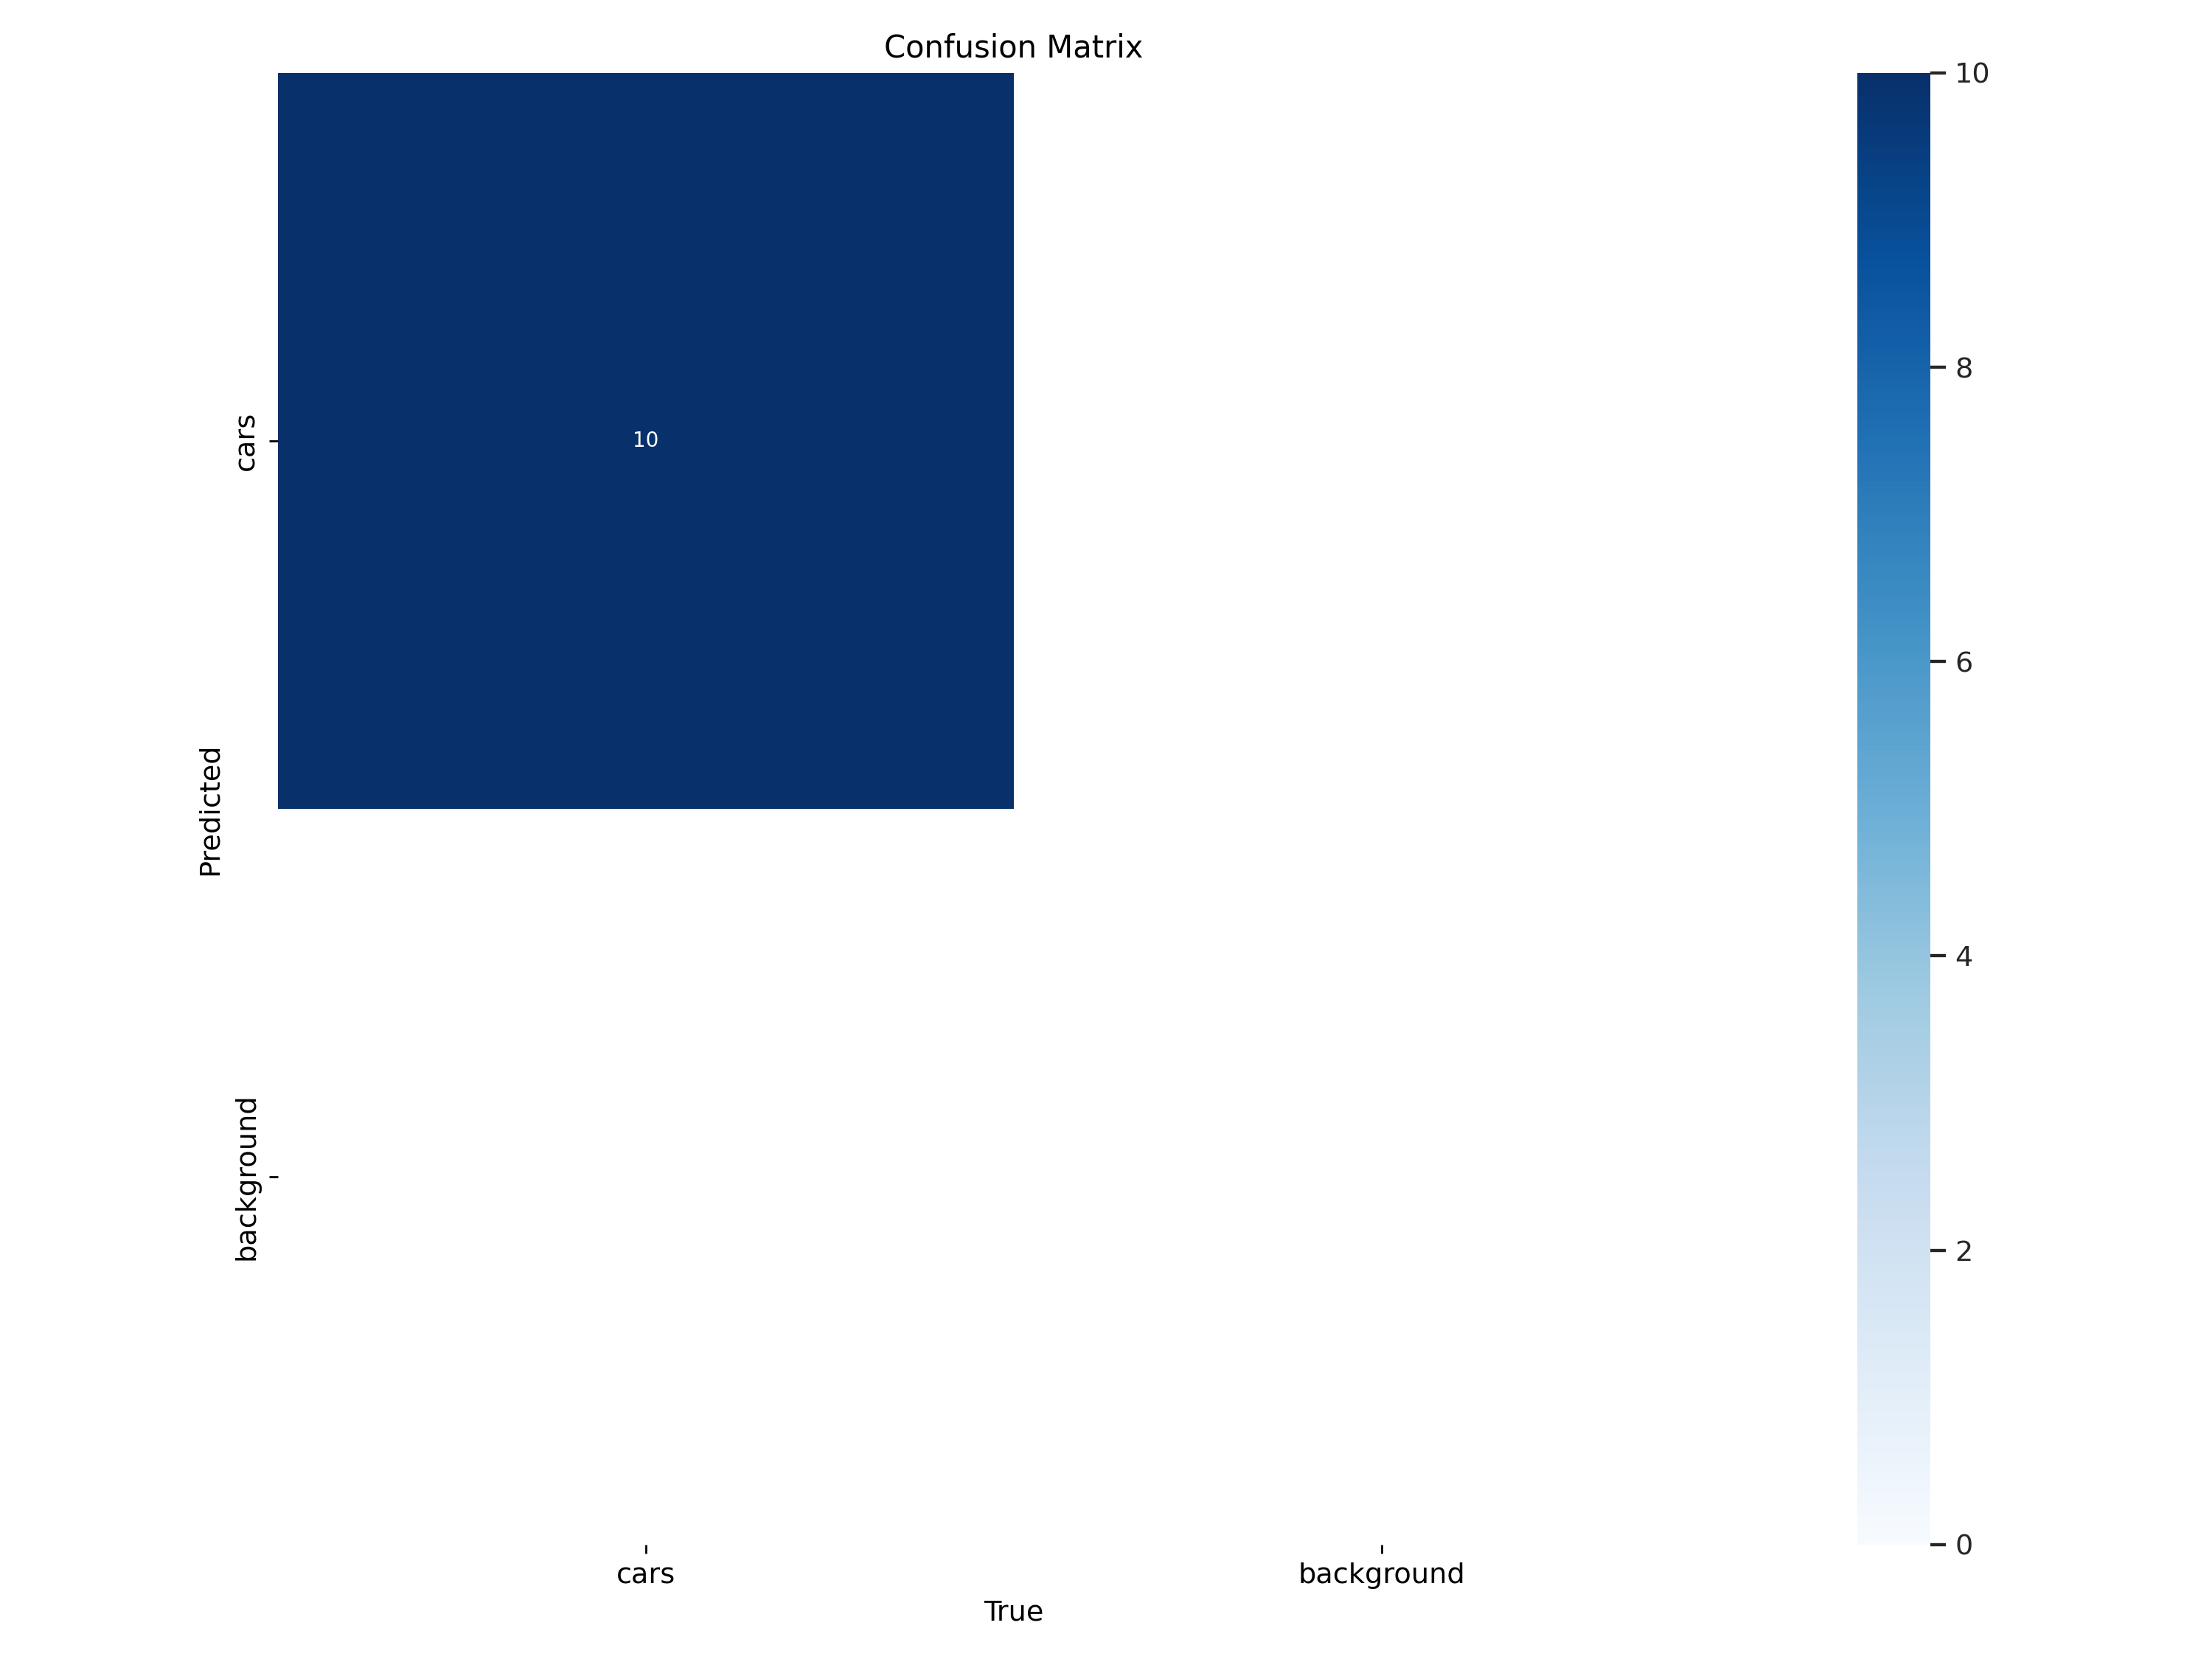

In [17]:
%cd {HOME}
Image(filename=f'{HOME}/datasets/runs/detect/train/confusion_matrix.png', width=600)

In [18]:
%load_ext tensorboard